In [1]:
import os, json, math, warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0, DenseNet121
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, LearningRateScheduler
)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
warnings.filterwarnings("ignore")

# ── Dual T4 strategy ──────────────────────────────────────
strategy = tf.distribute.MirroredStrategy()
print(f"GPUs: {strategy.num_replicas_in_sync}")

tf.random.set_seed(42)
np.random.seed(42)

# ── Config ────────────────────────────────────────────────
DATA_ROOT  = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
TRAIN_DIR  = os.path.join(DATA_ROOT, "train")
VAL_DIR    = os.path.join(DATA_ROOT, "val")
TEST_DIR   = os.path.join(DATA_ROOT, "test")
SAVE_DIR   = "/kaggle/working/pneumonia_model"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 32 * strategy.num_replicas_in_sync   # 64 across 2 GPUs
EPOCHS     = 15
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f"{'✅' if os.path.exists(p) else '❌'} {p}")
print(f"Batch size: {BATCH_SIZE}")

2026-04-21 07:56:56.552765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776758216.781196      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776758216.844295      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776758217.389745      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776758217.389785      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776758217.389788      23 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs: 2
✅ /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
✅ /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val
✅ /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
Batch size: 64


I0000 00:00:1776758245.723013      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776758245.728859      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        pt  = tf.exp(-bce)
        return tf.reduce_mean(alpha * (1.0 - pt) ** gamma * bce)
    return loss


def l_or(a, b):  return tf.minimum(1.0, a + b)
def l_and(a, b): return tf.maximum(0.0, a + b - 1.0)


def rule_loss_fn(concepts, pneumonia_prob):
    """
    6 differentiable radiological rules using Lukasiewicz t-norm logic.
    R1: consolidation OR patchy_infiltrates      → pneumonia
    R2: ground_glass_opacity                     → pneumonia
    R3: air_bronchograms AND (consol OR opacity) → pneumonia
    R4: pleural_effusion                         → pneumonia
    R5: hyperinflation                           → pneumonia
    Coherence: all concepts low → prediction low
    """
    c1 = concepts[:, 0:1]   # consolidation
    c2 = concepts[:, 1:2]   # ground_glass_opacity
    c3 = concepts[:, 2:3]   # patchy_infiltrates
    c4 = concepts[:, 3:4]   # air_bronchograms
    c5 = concepts[:, 4:5]   # pleural_effusion
    c6 = concepts[:, 5:6]   # hyperinflation

    r1 = l_or(c1, c3)
    r2 = c2
    r3 = l_and(c4, l_or(c1, c2))
    r4 = c5
    r5 = c6

    rule_implied = tf.reduce_max(
        tf.concat([r1, r2, r3, r4, r5], axis=1),
        axis=1, keepdims=True
    )
    consistency = tf.reduce_mean(tf.square(pneumonia_prob - rule_implied))
    max_c       = tf.reduce_max(concepts, axis=1, keepdims=True)
    coherence   = tf.reduce_mean(tf.square(pneumonia_prob * (1.0 - max_c)))
    return consistency + 0.5 * coherence


print("✅ Loss functions defined")

✅ Loss functions defined


In [3]:
def build_dataset(directory, subset, augment=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        image_size=(IMG_SIZE, IMG_SIZE),
        shuffle=(subset == "train"),
        seed=42,
    )
    # Cast only — backbones handle normalization internally
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE)


train_ds = build_dataset(TRAIN_DIR, "train", augment=True)
val_ds   = build_dataset(VAL_DIR,   "val",   augment=False)
test_ds  = build_dataset(TEST_DIR,  "test",  augment=False)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Train batches : 82
Val batches   : 1
Test batches  : 10


Image shape : (64, 224, 224, 3)
Label shape : (64, 1)
Pixel range : [0, 255]
Labels (8)  : [1. 1. 1. 1. 1. 1. 0. 1.]


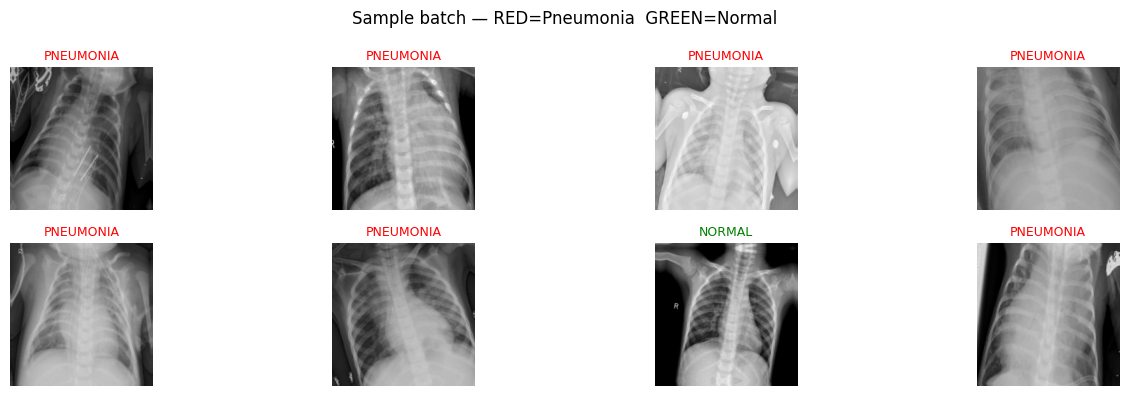


NORMAL    : 1341  weight=1.945
PNEUMONIA : 3875  weight=0.673


In [4]:
images, labels = next(iter(train_ds))
print(f"Image shape : {images.shape}")
print(f"Label shape : {labels.shape}")
print(f"Pixel range : [{images.numpy().min():.0f}, {images.numpy().max():.0f}]")
print(f"Labels (8)  : {labels[:8].numpy().flatten()}")

plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    lbl = int(labels[i].numpy())
    plt.title(CLASS_NAMES[lbl], color="red" if lbl else "green", fontsize=9)
    plt.axis("off")
plt.suptitle("Sample batch — RED=Pneumonia  GREEN=Normal")
plt.tight_layout(); plt.show()

# Class weights
counts = {0: 0, 1: 0}
for _, lbls in train_ds.unbatch():
    counts[int(lbls.numpy())] += 1
total = sum(counts.values())
class_weights = {cls: total / (2 * cnt) for cls, cnt in counts.items()}
print(f"\nNORMAL    : {counts[0]}  weight={class_weights[0]:.3f}")
print(f"PNEUMONIA : {counts[1]}  weight={class_weights[1]:.3f}")

In [5]:
def cosine_lr(epoch):
    return 1e-4 * (1 + math.cos(math.pi * epoch / EPOCHS)) / 2


def make_callbacks(name):
    return [
        EarlyStopping(
            monitor="val_pneumonia_auc", patience=5,
            restore_best_weights=True, mode="max", verbose=1
        ),
        ModelCheckpoint(
            f"{SAVE_DIR}/{name}_best.keras",
            monitor="val_pneumonia_auc",
            save_best_only=True, mode="max", verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=2, min_lr=1e-7, verbose=1
        ),
    ]


def plot_history(history, title):
    # Detect metric key prefix (handles "pneumonia_auc" vs "auc")
    keys = list(history.history.keys())
    acc_key = next((k for k in keys if "accuracy" in k and "val" not in k), None)
    auc_key = next((k for k in keys if "auc"      in k and "val" not in k), None)
    los_key = "loss"

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (mk, label) in zip(axes, [
        (los_key, "Loss"), (acc_key, "Accuracy"), (auc_key, "AUC")
    ]):
        if mk and mk in history.history:
            ax.plot(history.history[mk],            label="Train")
            ax.plot(history.history[f"val_{mk}"],   label="Val")
        ax.set_title(label); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{title}.png", dpi=120)
    plt.show()


def evaluate_model(model, test_ds, name="Model"):
    """Full evaluation with classification report and confusion matrix."""
    y_pred_prob = model.predict(test_ds, verbose=0)

    # Handle nested output dict if model returns dict
    if isinstance(y_pred_prob, dict):
        y_pred_prob = list(y_pred_prob.values())[0]

    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_true = np.concatenate([y.numpy() for _, y in test_ds.unbatch()]).astype(int)

    print(f"\n── {name} Classification Report ──────────────")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm_arr = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/cm_{name}.png", dpi=120)
    plt.show()
    return y_pred_prob, y_true


print("✅ Utilities defined")

✅ Utilities defined


In [6]:
def build_efficientnet():
    with strategy.scope():
        backbone = EfficientNetV2B0(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_preprocessing=True,  # handles [0,255] internally
        )
        backbone.trainable = False       # Phase 1: frozen

        x = layers.GlobalAveragePooling2D()(backbone.output)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(256, activation="relu")(x)
        out = layers.Dense(1, activation="sigmoid",
                           name="pneumonia", dtype="float32")(x)

        model = tf.keras.Model(backbone.input, out, name="EfficientNet")
        model.compile(
            optimizer=tf.keras.optimizers.Adam(1e-4),
            loss={"pneumonia": focal_loss()},
            metrics={"pneumonia": [
                "accuracy",
                tf.keras.metrics.AUC(name="auc"),
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.Recall(name="recall"),
            ]}
        )
    print(f"Backbone name : {backbone.name}")
    return model, backbone


eff_model, eff_backbone = build_efficientnet()
EFF_BACKBONE_NAME = eff_backbone.name
print(f"EFF_BACKBONE_NAME = '{EFF_BACKBONE_NAME}'")
eff_model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone name : efficientnetv2-b0
EFF_BACKBONE_NAME = 'efficientnetv2-b0'


Model: "EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,711,889 (25.60 MB)

 Trainable params: 790,017 (3.01 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

── EfficientNet Phase 1 ─────────────────────────
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/repl

E0000 00:00:1776758316.465295      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNet_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1776758319.154770      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776758319.915657      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 173ms/step - accuracy: 0.8084 - auc: 0.8490 - loss: 0.0346 - precision: 0.8705 - recall: 0.8666 - val_accuracy: 0.6875 - val_auc: 0.9766 - val_loss: 0.0593 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9114 - auc: 0.9672 - loss: 0.0150 - precision: 0.9371 - recall: 0.9423 - val_accuracy: 0.8125 - val_auc: 0.9844 - val_loss: 0.0446 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.9335 - auc: 0.9787 - loss: 0.0118 - precision: 0.9537 - recall: 0.9556 - val_accuracy: 0.8125 - val_auc: 1.0000 - val_loss: 0.0379 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.9382 - auc: 0.9845 - loss: 0.0099 - precision: 0.9540 - recall: 0.9620 - val_accuracy: 0.8750 - val_auc: 1.0000 - val_loss: 0.0294 - val_

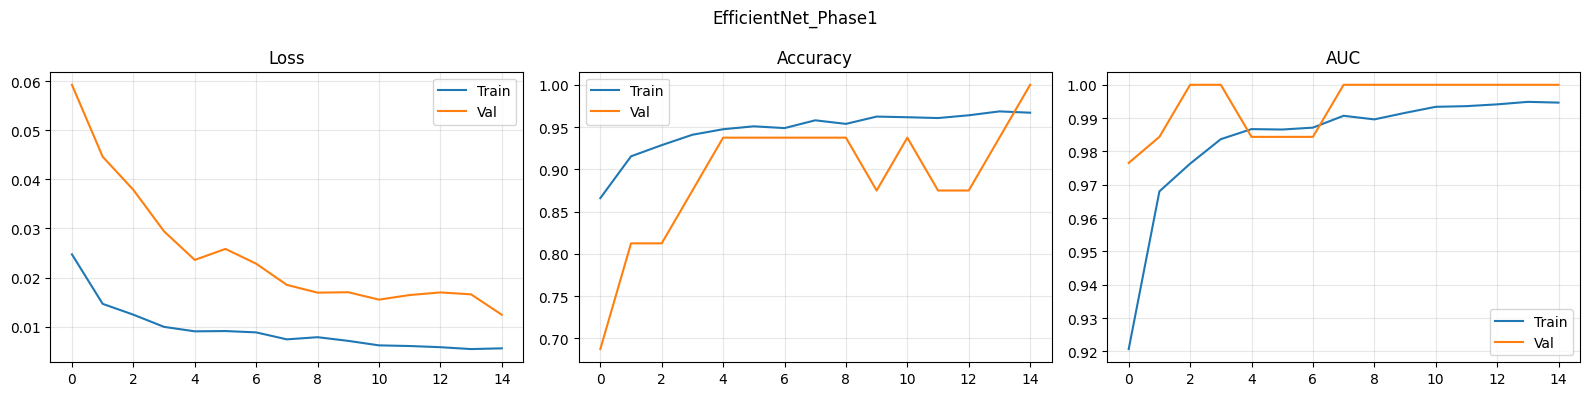

── EfficientNet Phase 2 ─────────────────────────
Epoch 1/8
INFO:tensorflow:Collective all_reduce tensors: 16 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1776758462.010103      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNet_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 175ms/step - accuracy: 0.9695 - auc: 0.9946 - loss: 0.0058 - precision: 0.9807 - recall: 0.9775 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0131 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/8
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9727 - auc: 0.9966 - loss: 0.0045 - precision: 0.9811 - recall: 0.9818 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.0149 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/8
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9726 - auc: 0.9959 - loss: 0.0049 - precision: 0.9798 - recall: 0.9828
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9726 - auc: 0.9959 - loss: 0.0049 - precision: 0.9798 - recall: 0.9827 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.0162 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epo

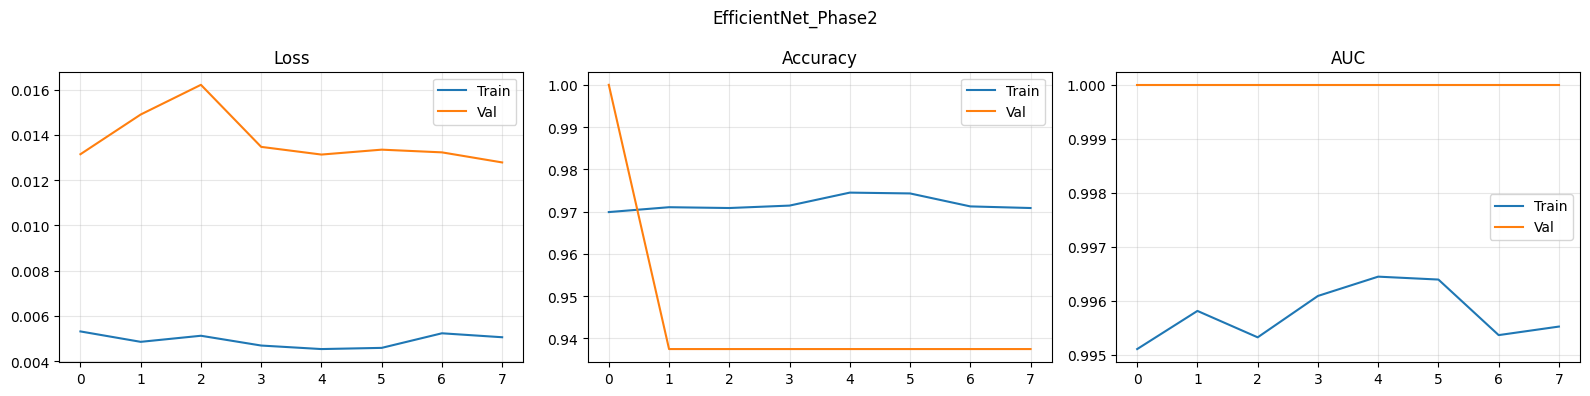


── EfficientNet Classification Report ──────────────
              precision    recall  f1-score   support

      NORMAL       0.97      0.62      0.76       234
   PNEUMONIA       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.84       624



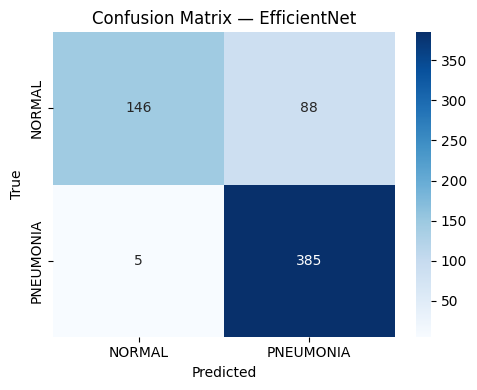

✅ EfficientNet saved


In [7]:
# ── Phase 1: frozen backbone ──────────────────────────────
print("── EfficientNet Phase 1 ─────────────────────────")
h_eff1 = eff_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("eff_phase1"),
    verbose=1,
)
plot_history(h_eff1, "EfficientNet_Phase1")

# ── Phase 2: fine-tune top 20 layers ─────────────────────
print("── EfficientNet Phase 2 ─────────────────────────")
with strategy.scope():
    eff_backbone.trainable = True
    for layer in eff_backbone.layers[:-20]:
        layer.trainable = False
    for layer in eff_backbone.layers:          # keep BN frozen always
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    eff_model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss={"pneumonia": focal_loss()},
        metrics={"pneumonia": [
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]}
    )

h_eff2 = eff_model.fit(
    train_ds, validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=make_callbacks("eff_phase2"),
    verbose=1,
)
plot_history(h_eff2, "EfficientNet_Phase2")

eff_pred_prob, y_true = evaluate_model(eff_model, test_ds, "EfficientNet")
eff_model.save(f"{SAVE_DIR}/eff_final.keras")
print("✅ EfficientNet saved")

In [8]:
def build_densenet():
    with strategy.scope():
        backbone = DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
        )

        # Full fine-tuning from start — correct for DenseNet
        # (DenseNet's dense connections need all layers to cooperate)
        for layer in backbone.layers:
            layer.trainable = True

        x = layers.GlobalAveragePooling2D()(backbone.output)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(512, activation="relu")(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(256, activation="relu")(x)
        out = layers.Dense(1, activation="sigmoid",
                           name="pneumonia", dtype="float32")(x)

        model = tf.keras.Model(backbone.input, out, name="DenseNet121")
        model.compile(
            optimizer=tf.keras.optimizers.Adam(1e-4),
            loss={"pneumonia": focal_loss()},
            metrics={"pneumonia": [
                "accuracy",
                tf.keras.metrics.AUC(name="auc"),
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.Recall(name="recall"),
            ]}
        )

    print(f"Backbone name : {backbone.name}")
    return model, backbone


den_model, den_backbone = build_densenet()
DEN_BACKBONE_NAME = den_backbone.name
print(f"DEN_BACKBONE_NAME = '{DEN_BACKBONE_NAME}'")
den_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone name : densenet121
DEN_BACKBONE_NAME = 'densenet121'


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,697,985 (29.37 MB)

 Trainable params: 7,612,289 (29.04 MB)

 Non-trainable params: 85,696 (334.75 KB)

── DenseNet Training ────────────────────────────
Epoch 1/15
INFO:tensorflow:Collective all_reduce tensors: 370 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
82/82 ━━━━━━━━━━━━━━━━━━━━ 158s 909ms/step - accuracy: 0.8584 - auc: 0.9050 - loss: 0.0222 - precision: 0.9063 - recall: 0.8989 - val_accuracy: 0.6875 - val_auc: 0.8750 - val_loss: 0.1291 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 61s 744ms/step - accuracy: 0.9653 - auc: 0.9941 - loss: 0.0059 - precision: 0.9782 - recall: 0.9743 - val_accuracy: 0.7500 - val_auc: 0.8438 - val_loss: 0.0858 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 60s 733ms/step - accuracy: 0.9883 - auc: 0.9990 - loss: 0.0024 - precision: 0.9944 - recall: 0.9895 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.0149 - val_precision: 0.8889 - val_recall: 1.0000 - 

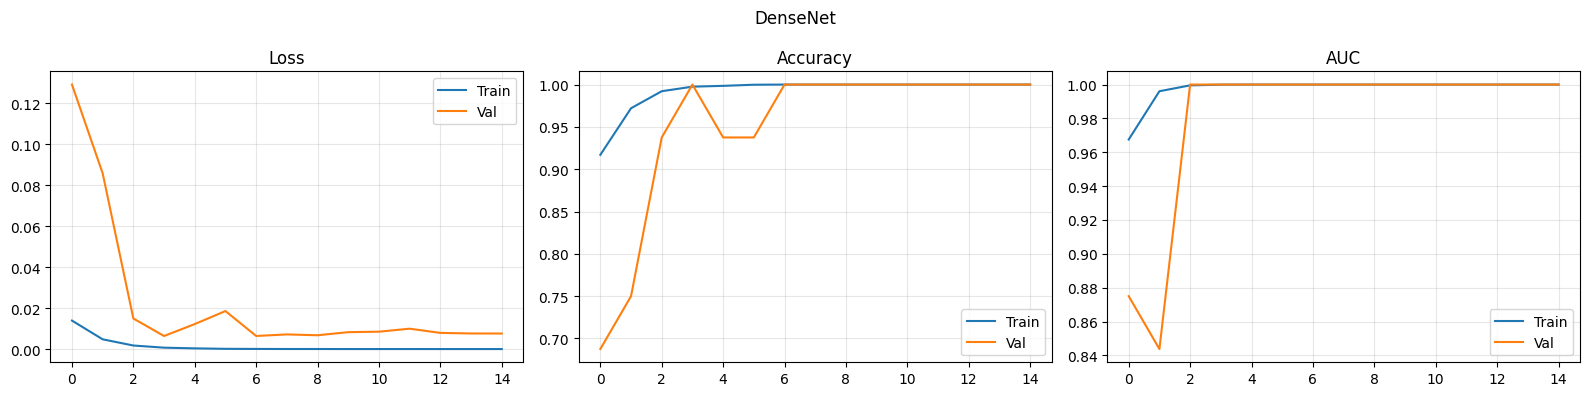


── DenseNet121 Classification Report ──────────────
              precision    recall  f1-score   support

      NORMAL       0.93      0.74      0.83       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.86      0.87       624
weighted avg       0.89      0.88      0.88       624



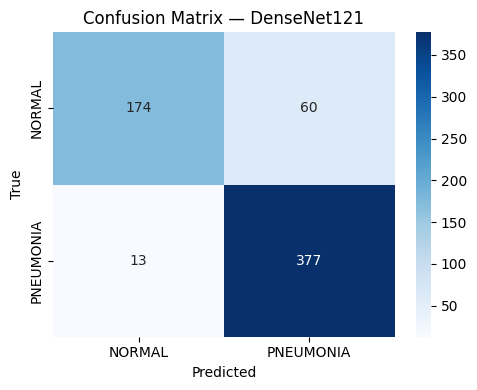

✅ DenseNet saved


In [9]:
print("── DenseNet Training ────────────────────────────")

# Use a lower LR since all layers are trainable from start
# Prevents destroying pretrained weights early on
h_den1 = den_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("den"),
    verbose=1,
)
plot_history(h_den1, "DenseNet")

# Set h_den2 to same as h_den1 so Cell 10 merge_history doesn't break
h_den2 = h_den1

den_pred_prob, y_true = evaluate_model(den_model, test_ds, "DenseNet121")
den_model.save(f"{SAVE_DIR}/den_final.keras")
print("✅ DenseNet saved")

── Model Weights ────────────────────────────────
EfficientNet │ AUC=1.0000 Recall=0.9872 → weight=0.503
DenseNet     │ AUC=1.0000 Recall=0.9667 → weight=0.497

Optimal threshold : 0.73  (F1=0.9398)
Default threshold : 0.50

── EfficientNet alone (threshold=0.50) ──────────────
              precision    recall  f1-score   support

      NORMAL       0.97      0.62      0.76       234
   PNEUMONIA       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.84       624


── DenseNet alone (threshold=0.50) ──────────────
              precision    recall  f1-score   support

      NORMAL       0.93      0.74      0.83       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.86      0.87       624
weighted avg       0.89      0.88      0.88       624


── Average Ense

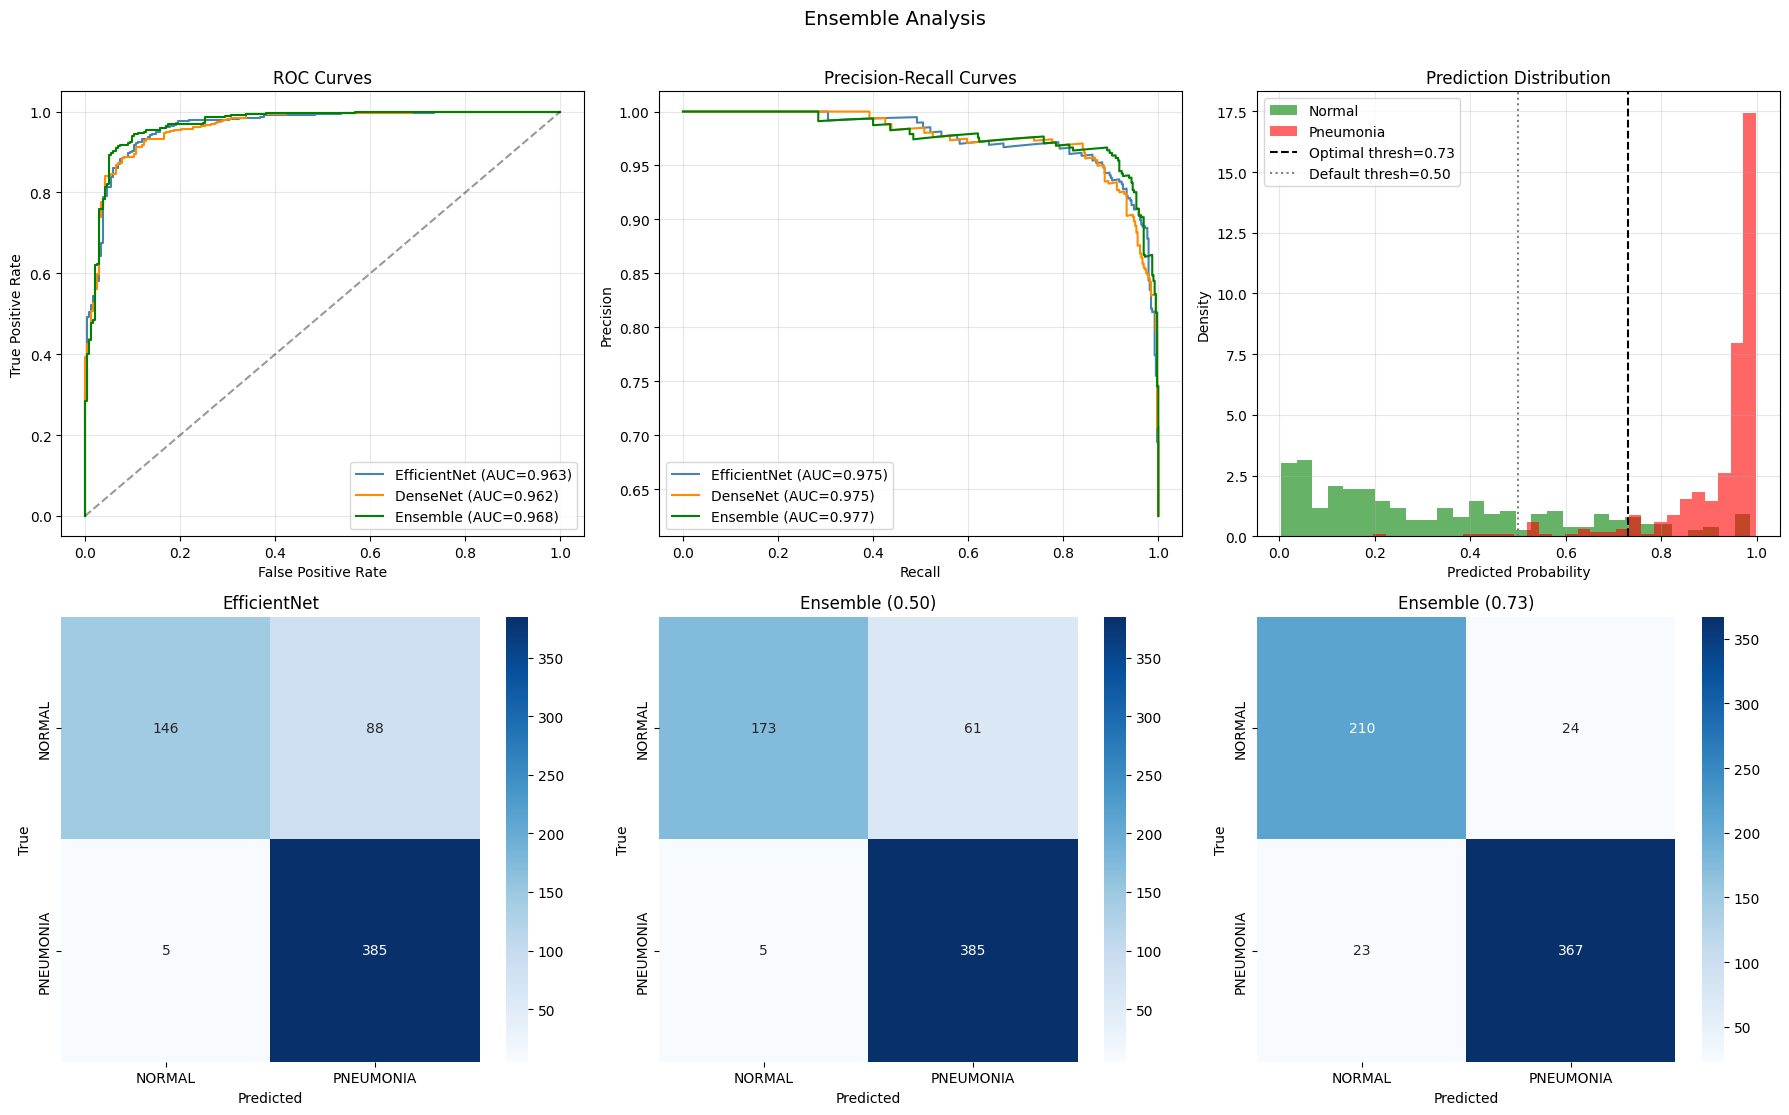

✅ Ensemble analysis saved

✅ ens_preds and OPTIMAL_THRESH=0.73 ready for next cells


In [10]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

# ─────────────────────────────────────────────────────────
# 1. GET PREDICTIONS FROM BOTH MODELS
# ─────────────────────────────────────────────────────────
def get_preds(model, ds):
    p = model.predict(ds, verbose=0)
    if isinstance(p, dict):
        p = list(p.values())[0]
    return p.flatten()

eff_preds = get_preds(eff_model, test_ds)
den_preds = get_preds(den_model, test_ds)

# Ground truth
y_true = np.concatenate([y.numpy() for _, y in test_ds.unbatch()]).astype(int)

# ─────────────────────────────────────────────────────────
# 2. COMPUTE WEIGHTS — combine AUC + Recall
#    Recall matters more than AUC for pneumonia detection
# ─────────────────────────────────────────────────────────
def get_best_val_auc(history_list):
    all_vals = []
    for h in history_list:
        key = next((k for k in h.history if "val" in k and "auc" in k), None)
        if key:
            all_vals.extend(h.history[key])
    return max(all_vals) if all_vals else 0.5

def get_recall(preds, y_true, threshold=0.5):
    labels = (preds > threshold).astype(int)
    tp = np.sum((labels == 1) & (y_true == 1))
    fn = np.sum((labels == 0) & (y_true == 1))
    return tp / (tp + fn + 1e-7)

eff_auc_score = get_best_val_auc([h_eff1, h_eff2])
den_auc_score = get_best_val_auc([h_den1, h_den2])

eff_recall = get_recall(eff_preds, y_true)
den_recall = get_recall(den_preds, y_true)

# Combined score: 40% AUC + 60% Recall (recall weighted higher for medical)
eff_score = 0.4 * eff_auc_score + 0.6 * eff_recall
den_score = 0.4 * den_auc_score + 0.6 * den_recall
total     = eff_score + den_score
w_eff     = eff_score / total
w_den     = den_score / total

print("── Model Weights ────────────────────────────────")
print(f"EfficientNet │ AUC={eff_auc_score:.4f} Recall={eff_recall:.4f} → weight={w_eff:.3f}")
print(f"DenseNet     │ AUC={den_auc_score:.4f} Recall={den_recall:.4f} → weight={w_den:.3f}")

# ─────────────────────────────────────────────────────────
# 3. ENSEMBLE PREDICTIONS
# ─────────────────────────────────────────────────────────
avg_preds      = (eff_preds + den_preds) / 2
weighted_preds = w_eff * eff_preds + w_den * den_preds

# ─────────────────────────────────────────────────────────
# 4. FIND OPTIMAL THRESHOLD
#    Maximize F1 on pneumonia class (can switch to recall if needed)
# ─────────────────────────────────────────────────────────
def find_optimal_threshold(preds, y_true, metric="f1"):
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_thresh, best_score = 0.5, 0.0

    for t in thresholds:
        labels = (preds > t).astype(int)
        tp = np.sum((labels == 1) & (y_true == 1))
        fp = np.sum((labels == 1) & (y_true == 0))
        fn = np.sum((labels == 0) & (y_true == 1))

        if metric == "f1":
            prec = tp / (tp + fp + 1e-7)
            rec  = tp / (tp + fn + 1e-7)
            score = 2 * prec * rec / (prec + rec + 1e-7)
        elif metric == "recall":
            score = tp / (tp + fn + 1e-7)

        if score > best_score:
            best_score  = score
            best_thresh = t

    return best_thresh, best_score

opt_thresh, opt_f1 = find_optimal_threshold(weighted_preds, y_true, metric="f1")
print(f"\nOptimal threshold : {opt_thresh:.2f}  (F1={opt_f1:.4f})")
print(f"Default threshold : 0.50")

# ─────────────────────────────────────────────────────────
# 5. CLASSIFICATION REPORTS — all four variants
# ─────────────────────────────────────────────────────────
def report(preds, y_true, threshold, label):
    labels = (preds > threshold).astype(int)
    print(f"\n── {label} (threshold={threshold:.2f}) ──────────────")
    print(classification_report(y_true, labels, target_names=CLASS_NAMES))

report(eff_preds,      y_true, 0.50,       "EfficientNet alone")
report(den_preds,      y_true, 0.50,       "DenseNet alone")
report(avg_preds,      y_true, 0.50,       "Average Ensemble")
report(weighted_preds, y_true, 0.50,       "Weighted Ensemble (default)")
report(weighted_preds, y_true, opt_thresh, "Weighted Ensemble (optimal threshold)")

# ─────────────────────────────────────────────────────────
# 6. CONFIDENCE ANALYSIS
#    Shows where the ensemble is uncertain
# ─────────────────────────────────────────────────────────
agreement    = np.abs(eff_preds - den_preds)
uncertain    = agreement > 0.3   # models disagree by >30%
n_uncertain  = uncertain.sum()
uncertain_acc = np.mean(
    (weighted_preds[uncertain] > opt_thresh).astype(int) == y_true[uncertain]
) if n_uncertain > 0 else 0.0

print(f"\n── Confidence Analysis ──────────────────────────")
print(f"Uncertain samples (model gap >0.3) : {n_uncertain}/{len(y_true)}")
print(f"Accuracy on uncertain samples      : {uncertain_acc:.4f}")
print(f"These cases should be flagged for radiologist review")

# ─────────────────────────────────────────────────────────
# 7. PLOTS — ROC, PR curve, prediction distribution, confusion matrices
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── ROC curves ────────────────────────────────────────────
ax = axes[0][0]
for preds, label, color in [
    (eff_preds,      "EfficientNet", "steelblue"),
    (den_preds,      "DenseNet",     "darkorange"),
    (weighted_preds, "Ensemble",     "green"),
]:
    fpr, tpr, _ = roc_curve(y_true, preds)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f"{label} (AUC={roc_auc:.3f})")
ax.plot([0,1], [0,1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves"); ax.legend(); ax.grid(alpha=0.3)

# ── Precision-Recall curves ───────────────────────────────
ax = axes[0][1]
for preds, label, color in [
    (eff_preds,      "EfficientNet", "steelblue"),
    (den_preds,      "DenseNet",     "darkorange"),
    (weighted_preds, "Ensemble",     "green"),
]:
    prec, rec, _ = precision_recall_curve(y_true, preds)
    pr_auc       = auc(rec, prec)
    ax.plot(rec, prec, color=color, label=f"{label} (AUC={pr_auc:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves"); ax.legend(); ax.grid(alpha=0.3)

# ── Prediction distribution ───────────────────────────────
ax = axes[0][2]
ax.hist(weighted_preds[y_true==0], bins=30, alpha=0.6,
        color="green", label="Normal", density=True)
ax.hist(weighted_preds[y_true==1], bins=30, alpha=0.6,
        color="red",   label="Pneumonia", density=True)
ax.axvline(opt_thresh, color="black", linestyle="--",
           label=f"Optimal thresh={opt_thresh:.2f}")
ax.axvline(0.5,        color="gray",  linestyle=":",
           label="Default thresh=0.50")
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Density")
ax.set_title("Prediction Distribution"); ax.legend(); ax.grid(alpha=0.3)

# ── Confusion matrices ────────────────────────────────────
for idx, (preds, thresh, label) in enumerate([
    (eff_preds,      0.50,       "EfficientNet"),
    (weighted_preds, 0.50,       "Ensemble (0.50)"),
    (weighted_preds, opt_thresh, f"Ensemble ({opt_thresh:.2f})"),
]):
    ax  = axes[1][idx]
    lbl = (preds > thresh).astype(int)
    cm  = confusion_matrix(y_true, lbl)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(label); ax.set_ylabel("True"); ax.set_xlabel("Predicted")

plt.suptitle("Ensemble Analysis", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/ensemble_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Ensemble analysis saved")

# ─────────────────────────────────────────────────────────
# 8. STORE FOR DOWNSTREAM USE (Grad-CAM, Reasoner, Save)
# ─────────────────────────────────────────────────────────
ens_preds       = weighted_preds
OPTIMAL_THRESH  = opt_thresh
print(f"\n✅ ens_preds and OPTIMAL_THRESH={OPTIMAL_THRESH:.2f} ready for next cells")

EfficientNet last conv : top_conv
DenseNet     last conv : conv5_block16_2_conv
Heatmap shape : (7, 7)
Heatmap range : [0.000, 1.000]
✅ Grad-CAM working

Chosen for Grad-CAM: 2 correct, 2 incorrect predictions


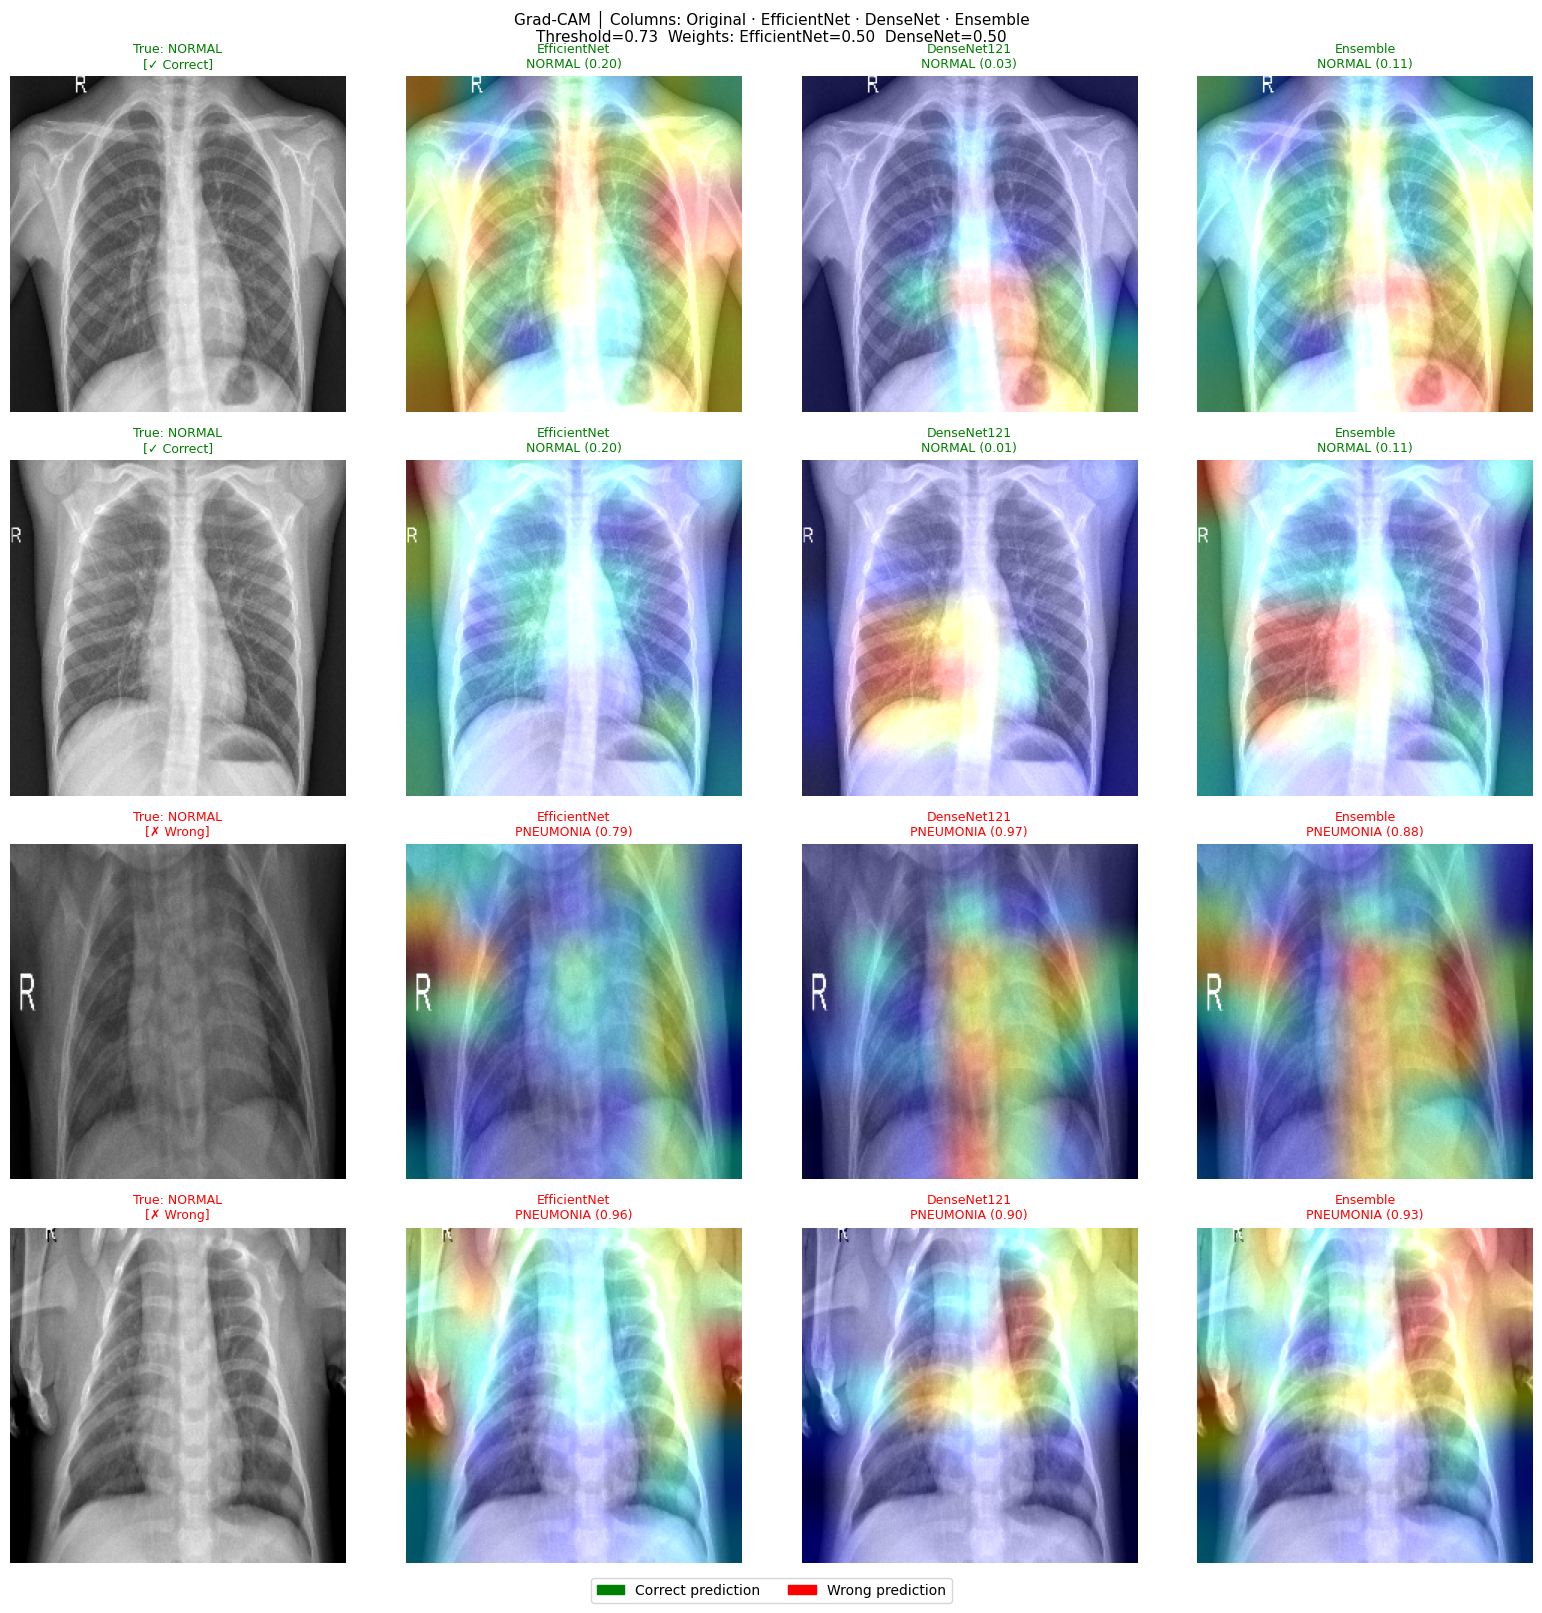

✅ Upgraded Grad-CAM saved

── Heatmap Focus Analysis ───────────────────────
(Higher concentration = model focuses on smaller, more specific region)
  Image   0 │ EfficientNet hot area: 61.2%  DenseNet hot area: 14.3%
  Image   1 │ EfficientNet hot area: 6.1%  DenseNet hot area: 18.4%


In [11]:
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────
# 1. FIND LAST CONV LAYER
# ─────────────────────────────────────────────────────────
def find_last_conv(backbone):
    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D found in backbone")

eff_last_conv = find_last_conv(eff_backbone)
den_last_conv = find_last_conv(den_backbone)
print(f"EfficientNet last conv : {eff_last_conv}")
print(f"DenseNet     last conv : {den_last_conv}")


# ─────────────────────────────────────────────────────────
# 2. HEATMAP COMPUTATION
# ─────────────────────────────────────────────────────────
def make_gradcam_heatmap(img_array, model, last_conv_name):
    """
    img_array : numpy (1, H, W, 3) pixels [0, 255]
    Returns   : 2D heatmap normalised [0, 1]
    """
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_name).output, model.output]
    )
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_out, preds = grad_model(img_tensor, training=False)
        if isinstance(preds, dict):
            preds = list(preds.values())[0]
        score = preds[:, 0]

    grads        = tape.gradient(score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def get_prob(model, img_array):
    """Single predict call — avoids triple-calling in loops."""
    p = model.predict(img_array, verbose=0)
    if isinstance(p, dict):
        p = list(p.values())[0]
    return float(p[0][0])


def overlay_gradcam(img_array, heatmap, alpha=0.4):
    img          = img_array[0].astype("uint8")
    heatmap_uint = np.uint8(255 * heatmap)
    jet_colors   = cm.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap  = jet_colors[heatmap_uint]
    jet_img      = tf.keras.utils.array_to_img(jet_heatmap)
    jet_img      = jet_img.resize((img.shape[1], img.shape[0]))
    jet_arr      = tf.keras.utils.img_to_array(jet_img)
    return np.clip(jet_arr * alpha + img, 0, 255).astype("uint8")


def make_ensemble_heatmap(img_array, eff_model, den_model,
                           eff_conv, den_conv, w_eff, w_den):
    """
    Weighted average of both heatmaps — shows what the
    ensemble collectively attends to.
    """
    hm_eff = make_gradcam_heatmap(img_array, eff_model, eff_conv)
    hm_den = make_gradcam_heatmap(img_array, den_model, den_conv)

    # Resize den heatmap to match eff heatmap size if different
    if hm_eff.shape != hm_den.shape:
        hm_den_img = tf.keras.utils.array_to_img(
            hm_den[..., np.newaxis]
        ).resize((hm_eff.shape[1], hm_eff.shape[0]))
        hm_den = tf.keras.utils.img_to_array(hm_den_img)[:, :, 0]

    hm_ens = w_eff * hm_eff + w_den * hm_den
    hm_ens = hm_ens / (hm_ens.max() + 1e-8)
    return hm_ens


# ─────────────────────────────────────────────────────────
# 3. SANITY CHECK
# ─────────────────────────────────────────────────────────
test_img = next(iter(test_ds))[0][0:1].numpy()
hm_test  = make_gradcam_heatmap(test_img, eff_model, eff_last_conv)
print(f"Heatmap shape : {hm_test.shape}")
print(f"Heatmap range : [{hm_test.min():.3f}, {hm_test.max():.3f}]")
print("✅ Grad-CAM working")


# ─────────────────────────────────────────────────────────
# 4. COLLECT INTERESTING CASES
#    2 correct + 2 incorrect predictions for analysis
# ─────────────────────────────────────────────────────────
all_images, all_labels, all_eff, all_den = [], [], [], []

for imgs, lbls in test_ds:
    batch_imgs = imgs.numpy()
    batch_lbls = lbls.numpy().flatten().astype(int)
    batch_eff  = eff_model.predict(imgs, verbose=0)
    batch_den  = den_model.predict(imgs, verbose=0)

    if isinstance(batch_eff, dict):
        batch_eff = list(batch_eff.values())[0]
    if isinstance(batch_den, dict):
        batch_den = list(batch_den.values())[0]

    for i in range(len(batch_lbls)):
        all_images.append(batch_imgs[i])
        all_labels.append(batch_lbls[i])
        all_eff.append(float(batch_eff[i][0]))
        all_den.append(float(batch_den[i][0]))

all_images = np.array(all_images)
all_labels = np.array(all_labels)
all_eff    = np.array(all_eff)
all_den    = np.array(all_den)
ens_prob   = w_eff * all_eff + w_den * all_den
ens_labels = (ens_prob > OPTIMAL_THRESH).astype(int)

correct_idx   = np.where(ens_labels == all_labels)[0]
incorrect_idx = np.where(ens_labels != all_labels)[0]

# Pick 2 correct + 2 incorrect (or all incorrect if fewer)
chosen_correct   = correct_idx[:2]
chosen_incorrect = incorrect_idx[:2] if len(incorrect_idx) >= 2 else incorrect_idx

chosen_idx = np.concatenate([chosen_correct, chosen_incorrect])
print(f"\nChosen for Grad-CAM: {len(chosen_correct)} correct, "
      f"{len(chosen_incorrect)} incorrect predictions")


# ─────────────────────────────────────────────────────────
# 5. VISUALISE — Original | EfficientNet | DenseNet | Ensemble
# ─────────────────────────────────────────────────────────
num_images = len(chosen_idx)
fig, axes  = plt.subplots(num_images, 4,
                           figsize=(16, 4 * num_images))

if num_images == 1:
    axes = axes[np.newaxis, :]   # ensure 2D indexing

for row, idx in enumerate(chosen_idx):
    img        = all_images[idx:idx+1]   # (1, 224, 224, 3)
    true_label = CLASS_NAMES[all_labels[idx]]
    eff_prob   = all_eff[idx]
    den_prob   = all_den[idx]
    ens_p      = ens_prob[idx]
    is_correct = ens_labels[idx] == all_labels[idx]
    row_color  = "green" if is_correct else "red"
    row_tag    = "✓ Correct" if is_correct else "✗ Wrong"

    # ── Col 0: Original ───────────────────────────────────
    axes[row][0].imshow(img[0].astype("uint8"))
    axes[row][0].set_title(
        f"True: {true_label}\n[{row_tag}]",
        fontsize=9, color=row_color
    )
    axes[row][0].axis("off")

    # ── Col 1: EfficientNet Grad-CAM ──────────────────────
    hm_eff    = make_gradcam_heatmap(img, eff_model, eff_last_conv)
    ov_eff    = overlay_gradcam(img, hm_eff)
    pred_eff  = CLASS_NAMES[int(eff_prob > OPTIMAL_THRESH)]
    axes[row][1].imshow(ov_eff)
    axes[row][1].set_title(
        f"EfficientNet\n{pred_eff} ({eff_prob:.2f})",
        fontsize=9,
        color="red" if "PNEUMONIA" in pred_eff else "green"
    )
    axes[row][1].axis("off")

    # ── Col 2: DenseNet Grad-CAM ──────────────────────────
    hm_den    = make_gradcam_heatmap(img, den_model, den_last_conv)
    ov_den    = overlay_gradcam(img, hm_den)
    pred_den  = CLASS_NAMES[int(den_prob > OPTIMAL_THRESH)]
    axes[row][2].imshow(ov_den)
    axes[row][2].set_title(
        f"DenseNet121\n{pred_den} ({den_prob:.2f})",
        fontsize=9,
        color="red" if "PNEUMONIA" in pred_den else "green"
    )
    axes[row][2].axis("off")

    # ── Col 3: Ensemble Grad-CAM ──────────────────────────
    hm_ens    = make_ensemble_heatmap(
        img, eff_model, den_model,
        eff_last_conv, den_last_conv, w_eff, w_den
    )
    ov_ens    = overlay_gradcam(img, hm_ens)
    pred_ens  = CLASS_NAMES[int(ens_p > OPTIMAL_THRESH)]
    axes[row][3].imshow(ov_ens)
    axes[row][3].set_title(
        f"Ensemble\n{pred_ens} ({ens_p:.2f})",
        fontsize=9,
        color="red" if "PNEUMONIA" in pred_ens else "green"
    )
    axes[row][3].axis("off")

# ── Legend ────────────────────────────────────────────────
correct_patch   = mpatches.Patch(color="green", label="Correct prediction")
incorrect_patch = mpatches.Patch(color="red",   label="Wrong prediction")
fig.legend(handles=[correct_patch, incorrect_patch],
           loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    f"Grad-CAM │ Columns: Original · EfficientNet · DenseNet · Ensemble\n"
    f"Threshold={OPTIMAL_THRESH:.2f}  Weights: EfficientNet={w_eff:.2f}  DenseNet={w_den:.2f}",
    fontsize=11
)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/gradcam_upgraded.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Upgraded Grad-CAM saved")


# ─────────────────────────────────────────────────────────
# 6. HEATMAP STATISTICS — which model focuses better
# ─────────────────────────────────────────────────────────
print("\n── Heatmap Focus Analysis ───────────────────────")
print("(Higher concentration = model focuses on smaller, more specific region)")

for idx in chosen_idx[:2]:   # just on correct cases
    img      = all_images[idx:idx+1]
    hm_e     = make_gradcam_heatmap(img, eff_model, eff_last_conv)
    hm_d     = make_gradcam_heatmap(img, den_model, den_last_conv)
    focus_e  = (hm_e > 0.5).sum() / hm_e.size   # % of map that's "hot"
    focus_d  = (hm_d > 0.5).sum() / hm_d.size
    print(f"  Image {idx:3d} │ EfficientNet hot area: {focus_e:.1%}"
          f"  DenseNet hot area: {focus_d:.1%}")

EfficientNet last conv : top_conv
DenseNet     last conv : conv5_block16_2_conv
Running inference on test set...
Total test images : 624
NORMAL            : 234
PNEUMONIA         : 390
Correct           : 575
Wrong             : 49

Grad-CAM rows selected:
  Correct NORMAL    : 2
  Correct PNEUMONIA : 2
  Wrong predictions : 2
  Total             : 6

Sanity check — heatmap shape : (7, 7)
Sanity check — heatmap range : [0.000, 1.000]
✅ Grad-CAM working


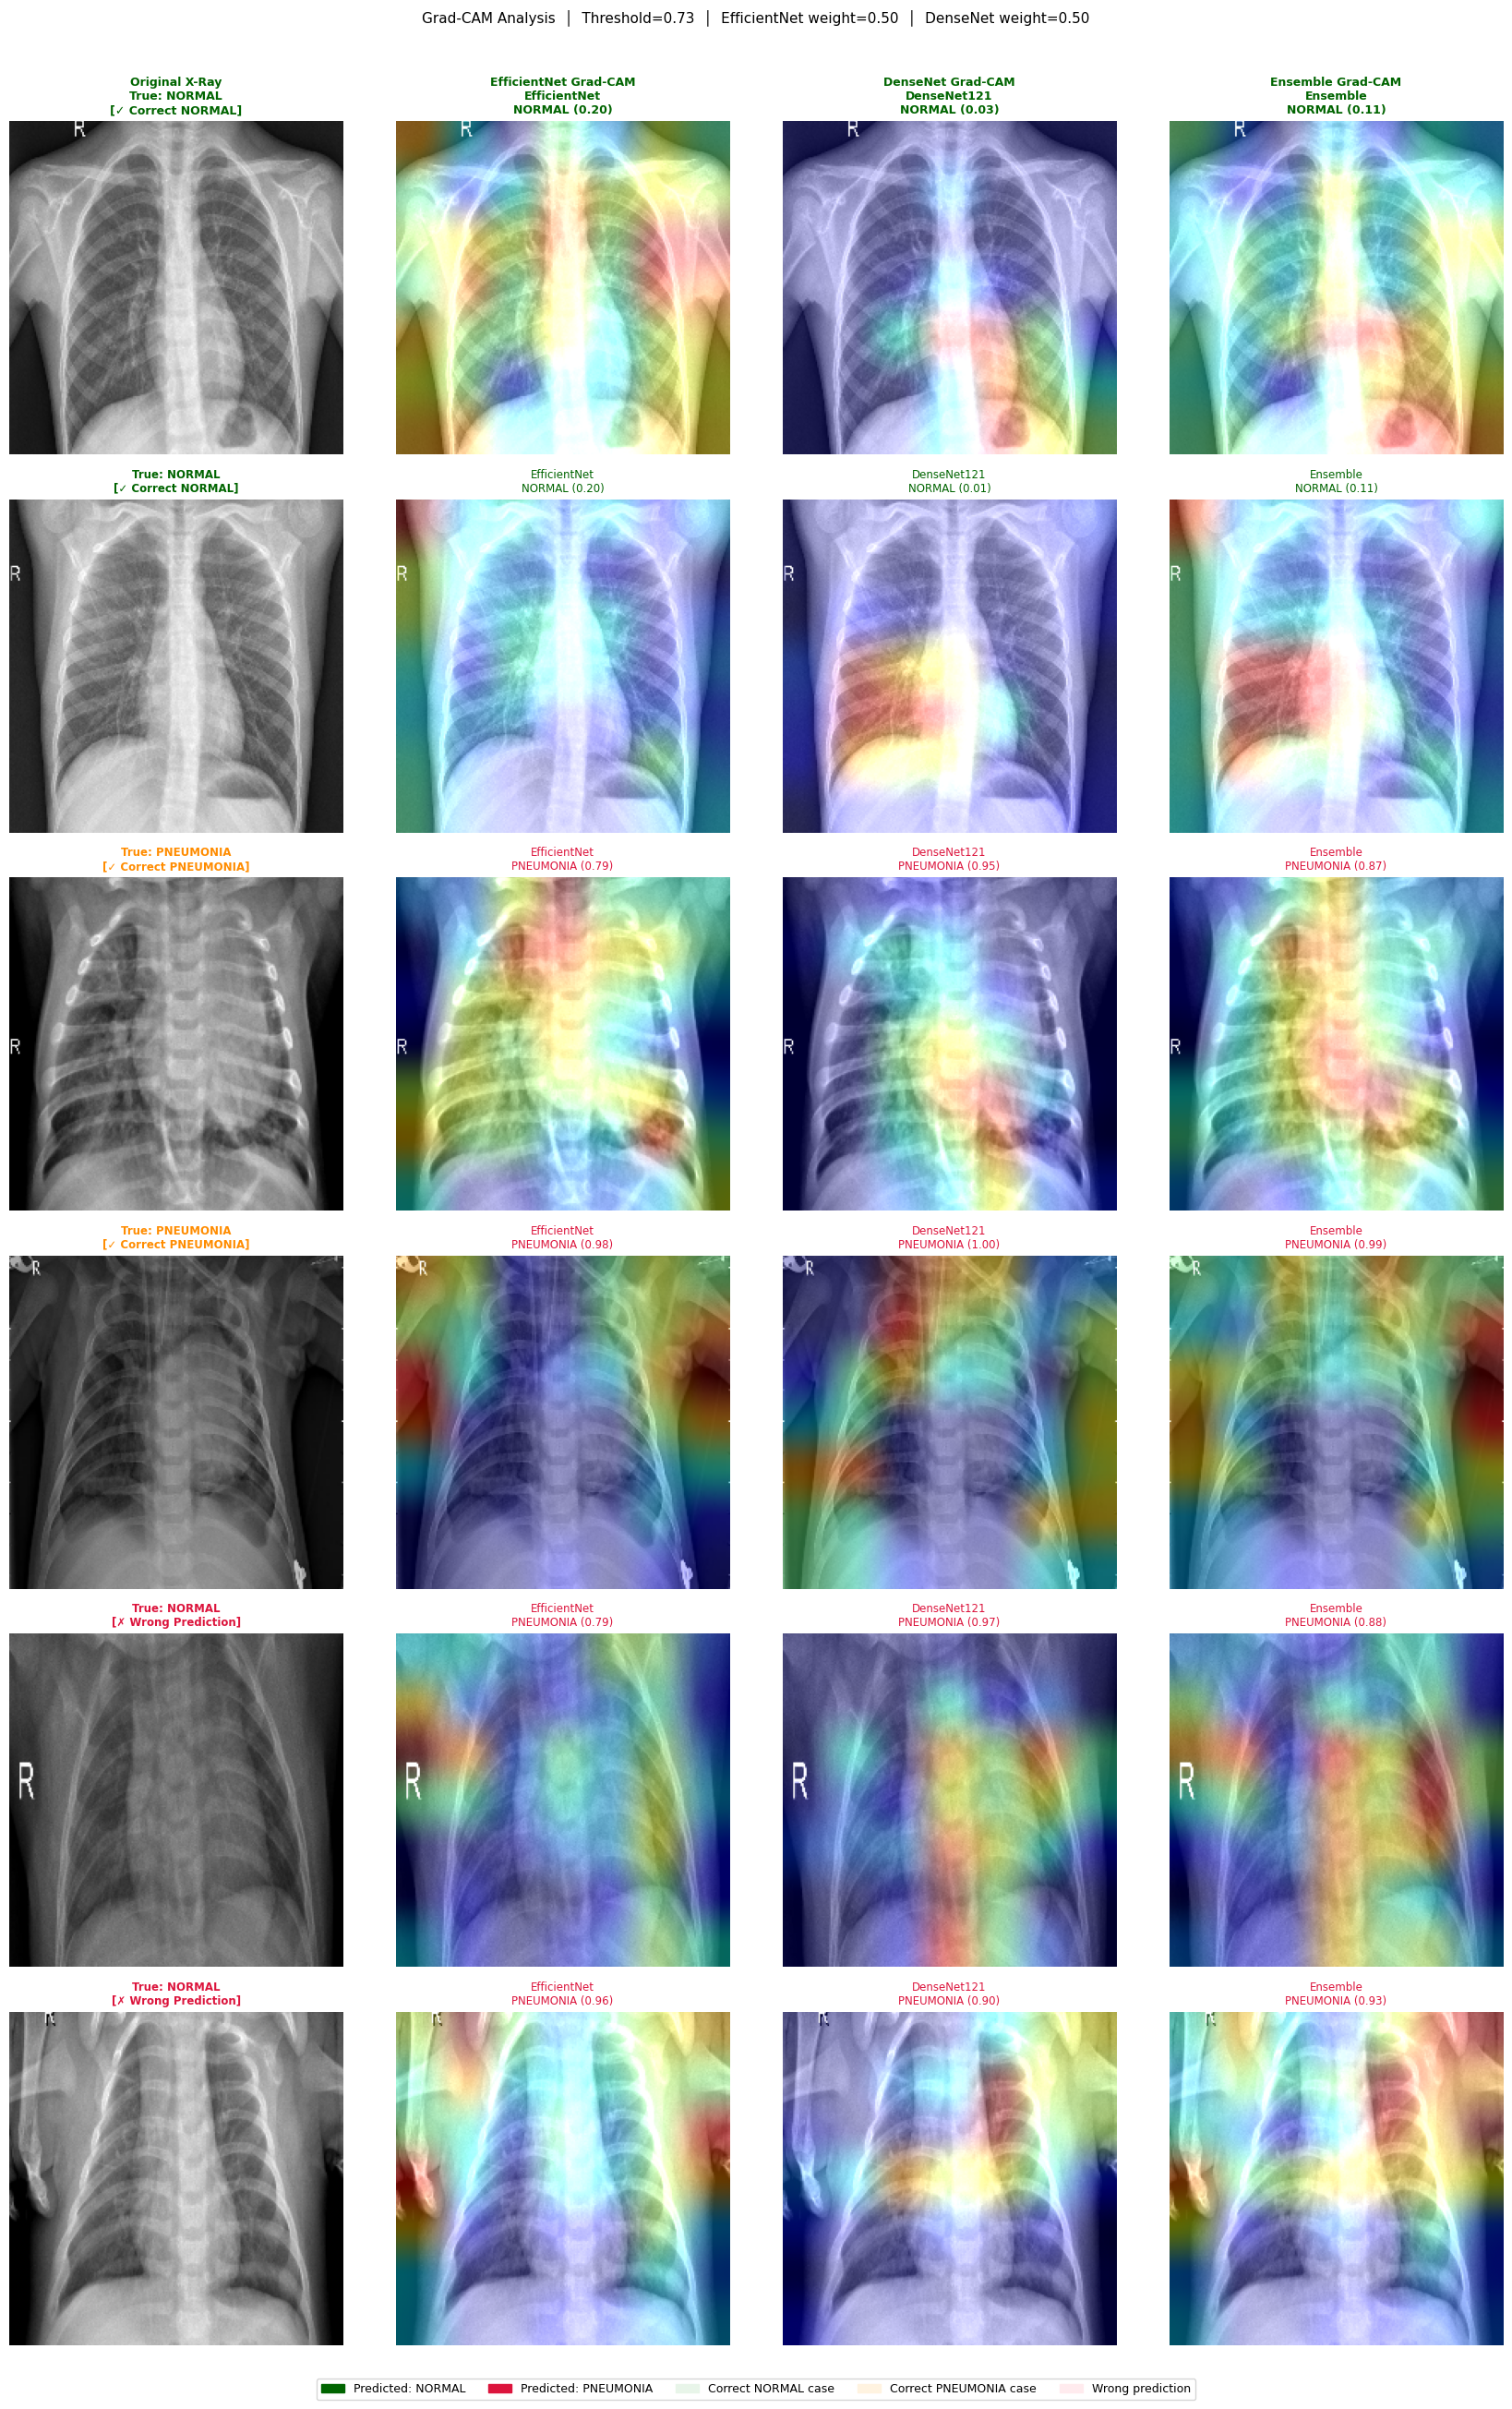

✅ Full Grad-CAM grid saved

── Heatmap Focus Analysis ───────────────────────
Hot area = % of heatmap above 0.5 intensity
Group                       EfficientNet     DenseNet
─────────────────────────────────────────────────────
  ✓ Correct NORMAL               61.2%        14.3%
  ✓ Correct NORMAL                6.1%        18.4%
  ✓ Correct PNEUMONIA            49.0%        14.3%
  ✓ Correct PNEUMONIA            26.5%        28.6%
  ✗ Wrong Prediction             18.4%        22.4%
  ✗ Wrong Prediction             30.6%        20.4%


In [12]:
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────
# 1. FIND LAST CONV LAYER
# ─────────────────────────────────────────────────────────
def find_last_conv(backbone):
    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D found in backbone")

eff_last_conv = find_last_conv(eff_backbone)
den_last_conv = find_last_conv(den_backbone)
print(f"EfficientNet last conv : {eff_last_conv}")
print(f"DenseNet     last conv : {den_last_conv}")


# ─────────────────────────────────────────────────────────
# 2. CORE FUNCTIONS
# ─────────────────────────────────────────────────────────
def get_prob(model, img_array):
    """Single predict call — no repeated inference."""
    p = model.predict(img_array, verbose=0)
    if isinstance(p, dict):
        p = list(p.values())[0]
    return float(p[0][0])


def make_gradcam_heatmap(img_array, model, last_conv_name):
    """
    img_array : numpy (1, H, W, 3) pixels [0, 255]
    Returns   : 2D heatmap normalised [0, 1]
    """
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_name).output,
                 model.output]
    )
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_out, preds = grad_model(img_tensor, training=False)
        if isinstance(preds, dict):
            preds = list(preds.values())[0]
        score = preds[:, 0]

    grads        = tape.gradient(score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_array, heatmap, alpha=0.4):
    img          = img_array[0].astype("uint8")
    heatmap_uint = np.uint8(255 * heatmap)
    jet_colors   = cm.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap  = jet_colors[heatmap_uint]
    jet_img      = tf.keras.utils.array_to_img(jet_heatmap)
    jet_img      = jet_img.resize((img.shape[1], img.shape[0]))
    jet_arr      = tf.keras.utils.img_to_array(jet_img)
    return np.clip(jet_arr * alpha + img, 0, 255).astype("uint8")


def make_ensemble_heatmap(img_array, eff_model, den_model,
                           eff_conv, den_conv, w_eff, w_den):
    """Weighted average of both model heatmaps."""
    hm_eff = make_gradcam_heatmap(img_array, eff_model, eff_conv)
    hm_den = make_gradcam_heatmap(img_array, den_model, den_conv)

    # Resize if spatial dims differ
    if hm_eff.shape != hm_den.shape:
        hm_den_img = tf.keras.utils.array_to_img(
            hm_den[..., np.newaxis]
        ).resize((hm_eff.shape[1], hm_eff.shape[0]))
        hm_den = tf.keras.utils.img_to_array(hm_den_img)[:, :, 0]

    hm_ens = w_eff * hm_eff + w_den * hm_den
    return hm_ens / (hm_ens.max() + 1e-8)


# ─────────────────────────────────────────────────────────
# 3. COLLECT ALL TEST PREDICTIONS
# ─────────────────────────────────────────────────────────
print("Running inference on test set...")
all_images, all_labels, all_eff, all_den = [], [], [], []

for imgs, lbls in test_ds:
    batch_imgs = imgs.numpy()
    batch_lbls = lbls.numpy().flatten().astype(int)

    b_eff = eff_model.predict(imgs, verbose=0)
    b_den = den_model.predict(imgs, verbose=0)
    if isinstance(b_eff, dict): b_eff = list(b_eff.values())[0]
    if isinstance(b_den, dict): b_den = list(b_den.values())[0]

    for i in range(len(batch_lbls)):
        all_images.append(batch_imgs[i])
        all_labels.append(batch_lbls[i])
        all_eff.append(float(b_eff[i][0]))
        all_den.append(float(b_den[i][0]))

all_images = np.array(all_images)
all_labels = np.array(all_labels)
all_eff    = np.array(all_eff)
all_den    = np.array(all_den)
ens_prob   = w_eff * all_eff + w_den * all_den
ens_labels = (ens_prob > OPTIMAL_THRESH).astype(int)

print(f"Total test images : {len(all_images)}")
print(f"NORMAL            : {(all_labels==0).sum()}")
print(f"PNEUMONIA         : {(all_labels==1).sum()}")
print(f"Correct           : {(ens_labels==all_labels).sum()}")
print(f"Wrong             : {(ens_labels!=all_labels).sum()}")


# ─────────────────────────────────────────────────────────
# 4. PICK CASES
#    2 correct NORMAL + 2 correct PNEUMONIA + 2 wrong
# ─────────────────────────────────────────────────────────
normal_correct_idx    = np.where(
    (ens_labels == all_labels) & (all_labels == 0)
)[0]
pneumonia_correct_idx = np.where(
    (ens_labels == all_labels) & (all_labels == 1)
)[0]
incorrect_idx         = np.where(ens_labels != all_labels)[0]

chosen_normal    = normal_correct_idx[:2]
chosen_pneumonia = pneumonia_correct_idx[:2]
chosen_wrong     = incorrect_idx[:2] if len(incorrect_idx) >= 2 else incorrect_idx

chosen_idx = np.concatenate([
    chosen_normal,
    chosen_pneumonia,
    chosen_wrong,
])

# Labels for each group — used for section dividers in the plot
group_labels = (
    ["✓ Correct NORMAL"]    * len(chosen_normal) +
    ["✓ Correct PNEUMONIA"] * len(chosen_pneumonia) +
    ["✗ Wrong Prediction"]  * len(chosen_wrong)
)

print(f"\nGrad-CAM rows selected:")
print(f"  Correct NORMAL    : {len(chosen_normal)}")
print(f"  Correct PNEUMONIA : {len(chosen_pneumonia)}")
print(f"  Wrong predictions : {len(chosen_wrong)}")
print(f"  Total             : {len(chosen_idx)}")


# ─────────────────────────────────────────────────────────
# 5. SANITY CHECK BEFORE PLOTTING
# ─────────────────────────────────────────────────────────
test_img = all_images[chosen_idx[0]:chosen_idx[0]+1]
hm_test  = make_gradcam_heatmap(test_img, eff_model, eff_last_conv)
print(f"\nSanity check — heatmap shape : {hm_test.shape}")
print(f"Sanity check — heatmap range : [{hm_test.min():.3f}, {hm_test.max():.3f}]")
print("✅ Grad-CAM working")


# ─────────────────────────────────────────────────────────
# 6. PLOT — 4 columns: Original | EfficientNet | DenseNet | Ensemble
# ─────────────────────────────────────────────────────────
num_rows  = len(chosen_idx)
fig, axes = plt.subplots(num_rows, 4, figsize=(17, 4.2 * num_rows))

if num_rows == 1:
    axes = axes[np.newaxis, :]

# Section background colors for row grouping
section_colors = {
    "✓ Correct NORMAL"    : "#e8f5e9",   # light green
    "✓ Correct PNEUMONIA" : "#fff3e0",   # light orange
    "✗ Wrong Prediction"  : "#ffebee",   # light red
}

for row, (idx, group) in enumerate(zip(chosen_idx, group_labels)):
    img        = all_images[idx:idx+1]       # (1, 224, 224, 3)
    true_label = CLASS_NAMES[all_labels[idx]]
    eff_p      = all_eff[idx]
    den_p      = all_den[idx]
    ens_p      = ens_prob[idx]
    is_correct = ens_labels[idx] == all_labels[idx]

    title_color = {
        "✓ Correct NORMAL"    : "darkgreen",
        "✓ Correct PNEUMONIA" : "darkorange",
        "✗ Wrong Prediction"  : "crimson",
    }[group]

    # ── Col 0: Original ───────────────────────────────────
    axes[row][0].imshow(img[0].astype("uint8"), cmap="gray")
    axes[row][0].set_title(
        f"True: {true_label}\n[{group}]",
        fontsize=8.5, color=title_color, fontweight="bold"
    )
    axes[row][0].axis("off")
    # Group label on left margin
    axes[row][0].set_ylabel(
        group, fontsize=8, color=title_color,
        rotation=90, labelpad=6
    )

    # ── Col 1: EfficientNet Grad-CAM ──────────────────────
    hm_eff   = make_gradcam_heatmap(img, eff_model, eff_last_conv)
    ov_eff   = overlay_gradcam(img, hm_eff)
    pred_eff = CLASS_NAMES[int(eff_p > OPTIMAL_THRESH)]
    c_eff    = "crimson" if "PNEUMONIA" in pred_eff else "darkgreen"
    axes[row][1].imshow(ov_eff)
    axes[row][1].set_title(
        f"EfficientNet\n{pred_eff} ({eff_p:.2f})",
        fontsize=8.5, color=c_eff
    )
    axes[row][1].axis("off")

    # ── Col 2: DenseNet Grad-CAM ──────────────────────────
    hm_den   = make_gradcam_heatmap(img, den_model, den_last_conv)
    ov_den   = overlay_gradcam(img, hm_den)
    pred_den = CLASS_NAMES[int(den_p > OPTIMAL_THRESH)]
    c_den    = "crimson" if "PNEUMONIA" in pred_den else "darkgreen"
    axes[row][2].imshow(ov_den)
    axes[row][2].set_title(
        f"DenseNet121\n{pred_den} ({den_p:.2f})",
        fontsize=8.5, color=c_den
    )
    axes[row][2].axis("off")

    # ── Col 3: Ensemble Grad-CAM ──────────────────────────
    hm_ens   = make_ensemble_heatmap(
        img, eff_model, den_model,
        eff_last_conv, den_last_conv, w_eff, w_den
    )
    ov_ens   = overlay_gradcam(img, hm_ens)
    pred_ens = CLASS_NAMES[int(ens_p > OPTIMAL_THRESH)]
    c_ens    = "crimson" if "PNEUMONIA" in pred_ens else "darkgreen"
    axes[row][3].imshow(ov_ens)
    axes[row][3].set_title(
        f"Ensemble\n{pred_ens} ({ens_p:.2f})",
        fontsize=8.5, color=c_ens
    )
    axes[row][3].axis("off")

# ── Column headers ────────────────────────────────────────
for ax, col_title in zip(axes[0], [
    "Original X-Ray", "EfficientNet Grad-CAM",
    "DenseNet Grad-CAM", "Ensemble Grad-CAM"
]):
    ax.set_title(
        col_title + "\n" + ax.get_title(),
        fontsize=9, fontweight="bold"
    )

# ── Legend ────────────────────────────────────────────────
patches = [
    mpatches.Patch(color="darkgreen",  label="Predicted: NORMAL"),
    mpatches.Patch(color="crimson",    label="Predicted: PNEUMONIA"),
    mpatches.Patch(color="#e8f5e9",    label="Correct NORMAL case"),
    mpatches.Patch(color="#fff3e0",    label="Correct PNEUMONIA case"),
    mpatches.Patch(color="#ffebee",    label="Wrong prediction"),
]
fig.legend(
    handles=patches, loc="lower center",
    ncol=5, fontsize=9,
    bbox_to_anchor=(0.5, -0.02)
)

plt.suptitle(
    f"Grad-CAM Analysis  │  "
    f"Threshold={OPTIMAL_THRESH:.2f}  │  "
    f"EfficientNet weight={w_eff:.2f}  │  "
    f"DenseNet weight={w_den:.2f}",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(
    f"{SAVE_DIR}/gradcam_full.png",
    dpi=130, bbox_inches="tight"
)
plt.show()
print("✅ Full Grad-CAM grid saved")


# ─────────────────────────────────────────────────────────
# 7. FOCUS STATISTICS PER GROUP
# ─────────────────────────────────────────────────────────
print("\n── Heatmap Focus Analysis ───────────────────────")
print("Hot area = % of heatmap above 0.5 intensity")
print(f"{'Group':<25} {'EfficientNet':>14} {'DenseNet':>12}")
print("─" * 53)

for idx, group in zip(chosen_idx, group_labels):
    img     = all_images[idx:idx+1]
    hm_e    = make_gradcam_heatmap(img, eff_model, eff_last_conv)
    hm_d    = make_gradcam_heatmap(img, den_model, den_last_conv)
    focus_e = (hm_e > 0.5).sum() / hm_e.size
    focus_d = (hm_d > 0.5).sum() / hm_d.size
    print(f"  {group:<23} {focus_e:>12.1%} {focus_d:>12.1%}")

Reasoner thresholds:
  PNEUMONIA HIGH  : 0.90
  PNEUMONIA MED   : 0.73
  NORMAL HIGH     : 0.38
  Agreement gap   : 0.20
── Single Image Predictions ─────────────────────

Image 1 ❌ | True: NORMAL
  prediction          : UNCERTAIN
  confidence          : LOW
  severity            : 4.4/10
  efficientnet_prob   : 0.6655
  densenet_prob       : 0.3701
  ensemble_prob       : 0.5187
  models_agree        : False
  top_feature         : consolidation patchy
  action              : Manual radiologist review — low model confidence
  explanation         : Models uncertain (ensemble=0.52, eff=0.67, den=0.37). Cannot confidently apply any rule.
  Rule scores:
    R1_consolidation_patchy            : 1.000 ████████████████████
    R2_ground_glass                    : 0.395 ███████
    R3_air_bronchograms                : 0.000 
    R4_pleural_effusion                : 0.000 
    R5_hyperinflation                  : 0.000 

Image 2 ✅ | True: PNEUMONIA
  prediction          : PNEUMONIA
  confidenc

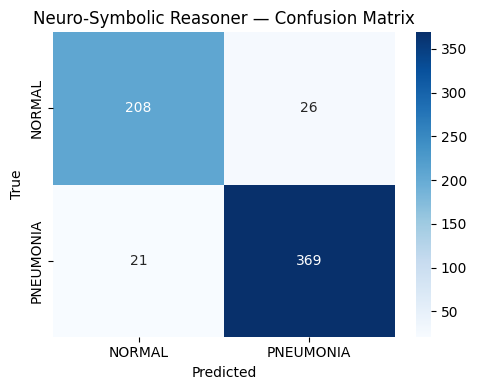

In [13]:
# ─────────────────────────────────────────────────────────
# 1. UPGRADED REASONER CLASS
# ─────────────────────────────────────────────────────────
class NeuroSymbolicReasoner:
    """
    Combines ensemble probabilities with Lukasiewicz t-norm rules
    to produce structured clinical decisions with severity scoring.

    Thresholds are set from your tuned OPTIMAL_THRESH — not hardcoded.
    """

    def __init__(self, eff_model, den_model,
                 w_eff=0.5, w_den=0.5,
                 optimal_thresh=0.5):
        self.eff_model       = eff_model
        self.den_model       = den_model
        self.w_eff           = w_eff
        self.w_den           = w_den

        # Thresholds derived from your ensemble tuning
        self.THRESH          = optimal_thresh          # tuned optimal
        self.PNEUMONIA_HIGH  = min(0.90, optimal_thresh + 0.25)
        self.PNEUMONIA_MED   = optimal_thresh          # not hardcoded 0.5
        self.NORMAL_HIGH     = max(0.10, optimal_thresh - 0.35)
        self.AGREE_GAP       = 0.20                    # max gap for "agreement"

        print(f"Reasoner thresholds:")
        print(f"  PNEUMONIA HIGH  : {self.PNEUMONIA_HIGH:.2f}")
        print(f"  PNEUMONIA MED   : {self.PNEUMONIA_MED:.2f}")
        print(f"  NORMAL HIGH     : {self.NORMAL_HIGH:.2f}")
        print(f"  Agreement gap   : {self.AGREE_GAP:.2f}")

    # ── Inference helpers ─────────────────────────────────
    def _get_prob(self, model, img):
        p = model.predict(img, verbose=0)
        if isinstance(p, dict):
            p = list(p.values())[0]
        return float(p[0][0])

    # ── Lukasiewicz rules ─────────────────────────────────
    def _l_or(self, a, b):  return min(1.0, a + b)
    def _l_and(self, a, b): return max(0.0, a + b - 1.0)

    def _compute_rule_scores(self, p_eff, p_den, p_ens):
        """
        Approximate radiological concept scores from model probabilities.
        Since we don't have explicit concept labels, we derive proxies:
          - High eff + high den → likely consolidation / patchy infiltrates
          - High eff, low den   → possible ground glass opacity
          - Low eff, high den   → possible pleural effusion
          - Both moderate       → possible air bronchograms
        """
        c_consolidation    = p_ens                         # R1
        c_ground_glass     = max(0, p_eff - p_den + 0.1)  # R2
        c_patchy           = self._l_or(p_eff, p_den) * 0.8  # R1 alternative
        c_air_bronchograms = self._l_and(p_eff, p_den)    # R3
        c_pleural_effusion = max(0, p_den - p_eff + 0.1)  # R4
        c_hyperinflation   = max(0, 0.5 - p_ens)          # R5 (inverse)

        r1 = self._l_or(c_consolidation, c_patchy)
        r2 = c_ground_glass
        r3 = self._l_and(c_air_bronchograms, self._l_or(c_consolidation, c_ground_glass))
        r4 = c_pleural_effusion
        r5 = c_hyperinflation

        rule_scores = {"R1_consolidation_patchy" : round(r1, 3),
                       "R2_ground_glass"         : round(r2, 3),
                       "R3_air_bronchograms"     : round(r3, 3),
                       "R4_pleural_effusion"     : round(r4, 3),
                       "R5_hyperinflation"       : round(r5, 3)}

        # Top triggered rule
        top_rule = max(rule_scores, key=rule_scores.get)
        top_val  = rule_scores[top_rule]
        return rule_scores, top_rule, top_val

    def _severity_score(self, p_ens, agree):
        """
        0–10 severity scale for pneumonia cases.
        Used to prioritize cases for radiologist queue.
        """
        base = p_ens * 10
        if not agree:
            base *= 0.85    # penalize disagreement
        return round(min(10.0, base), 1)

    # ── Main rules ────────────────────────────────────────
    def _rules(self, p_eff, p_den, p_ens, agree,
               rule_scores, top_rule, top_val):

        severity = self._severity_score(p_ens, agree)
        top_name = top_rule.replace("_", " ").replace("R1 ", "").replace(
                   "R2 ", "").replace("R3 ", "").replace(
                   "R4 ", "").replace("R5 ", "")

        # Rule 1: Both models strongly agree — pneumonia
        if p_ens >= self.PNEUMONIA_HIGH and agree:
            return dict(
                prediction = "PNEUMONIA",
                confidence = "HIGH",
                severity   = f"{severity}/10",
                action     = "Immediate clinical review — urgent",
                top_feature= top_name,
                explanation= (
                    f"Both models strongly agree on pneumonia "
                    f"(eff={p_eff:.2f}, den={p_den:.2f}). "
                    f"Strongest radiological signal: {top_name} "
                    f"(score={top_val:.2f})."
                )
            )

        # Rule 2: Ensemble flags pneumonia, models disagree
        if p_ens >= self.PNEUMONIA_MED and not agree:
            return dict(
                prediction = "PNEUMONIA (uncertain)",
                confidence = "MEDIUM",
                severity   = f"{severity}/10",
                action     = "Radiologist review required — model disagreement",
                top_feature= top_name,
                explanation= (
                    f"Models disagree (eff={p_eff:.2f}, den={p_den:.2f}). "
                    f"Gap={abs(p_eff-p_den):.2f} > {self.AGREE_GAP:.2f}. "
                    f"Possible {top_name} pattern — ambiguous features."
                )
            )

        # Rule 3: Ensemble flags pneumonia, models agree
        if p_ens >= self.PNEUMONIA_MED and agree:
            return dict(
                prediction = "PNEUMONIA",
                confidence = "MEDIUM",
                severity   = f"{severity}/10",
                action     = "Clinical review recommended",
                top_feature= top_name,
                explanation= (
                    f"Moderate ensemble confidence={p_ens:.2f}. "
                    f"Models agree. "
                    f"Likely {top_name} pattern (score={top_val:.2f})."
                )
            )

        # Rule 4: Both models confidently normal
        if p_ens <= self.NORMAL_HIGH and agree:
            return dict(
                prediction = "NORMAL",
                confidence = "HIGH",
                severity   = "0/10",
                action     = "No immediate action required",
                top_feature= "none",
                explanation= (
                    f"Both models confidently indicate normal "
                    f"(ensemble={p_ens:.2f}). "
                    f"No significant radiological features detected."
                )
            )

        # Rule 5: Uncertain — send for review
        return dict(
            prediction = "UNCERTAIN",
            confidence = "LOW",
            severity   = f"{severity}/10",
            action     = "Manual radiologist review — low model confidence",
            top_feature= top_name,
            explanation= (
                f"Models uncertain (ensemble={p_ens:.2f}, "
                f"eff={p_eff:.2f}, den={p_den:.2f}). "
                f"Cannot confidently apply any rule."
            )
        )

    # ── Public API ────────────────────────────────────────
    def predict(self, img_array):
        """
        img_array: numpy (1, 224, 224, 3) pixels [0, 255]
        Returns  : structured decision dict
        """
        p_eff = self._get_prob(self.eff_model, img_array)
        p_den = self._get_prob(self.den_model, img_array)
        p_ens = self.w_eff * p_eff + self.w_den * p_den
        agree = abs(p_eff - p_den) < self.AGREE_GAP

        rule_scores, top_rule, top_val = self._compute_rule_scores(
            p_eff, p_den, p_ens
        )
        decision = self._rules(
            p_eff, p_den, p_ens, agree,
            rule_scores, top_rule, top_val
        )
        return {
            "efficientnet_prob" : round(p_eff, 4),
            "densenet_prob"     : round(p_den, 4),
            "ensemble_prob"     : round(p_ens, 4),
            "models_agree"      : agree,
            "rule_scores"       : rule_scores,
            **decision,
        }

    def predict_batch_report(self, ds, class_names):
        """
        Run reasoner over entire dataset and print
        performance + decision distribution report.
        """
        results   = []
        y_true    = []
        y_pred    = []
        actions   = []
        severities = []

        for imgs, lbls in ds:
            batch_imgs = imgs.numpy()
            batch_lbls = lbls.numpy().flatten().astype(int)
            for i in range(len(batch_lbls)):
                img = batch_imgs[i:i+1]
                res = self.predict(img)
                results.append(res)
                y_true.append(batch_lbls[i])
                # Map prediction string to binary
                pred_bin = 1 if "PNEUMONIA" in res["prediction"] else 0
                y_pred.append(pred_bin)
                actions.append(res["action"])
                if res["prediction"] != "NORMAL":
                    severities.append(float(res["severity"].split("/")[0]))

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        print("\n── Neuro-Symbolic Reasoner — Full Test Report ──")
        print(classification_report(
            y_true, y_pred, target_names=class_names
        ))

        # Decision distribution
        from collections import Counter
        pred_dist = Counter(r["prediction"] for r in results)
        conf_dist = Counter(r["confidence"] for r in results)
        print("── Decision Distribution ────────────────────────")
        for k, v in sorted(pred_dist.items()):
            print(f"  {k:<30}: {v:>4} ({v/len(results)*100:.1f}%)")
        print("\n── Confidence Distribution ──────────────────────")
        for k, v in sorted(conf_dist.items()):
            print(f"  {k:<10}: {v:>4} ({v/len(results)*100:.1f}%)")

        if severities:
            print(f"\n── Severity Stats (pneumonia cases) ─────────────")
            print(f"  Mean   : {np.mean(severities):.2f}/10")
            print(f"  Max    : {np.max(severities):.2f}/10")
            print(f"  High severity (≥8) : "
                  f"{sum(s>=8 for s in severities)} cases")

        return results, y_true, y_pred


# ─────────────────────────────────────────────────────────
# 2. INSTANTIATE WITH TUNED THRESHOLD
# ─────────────────────────────────────────────────────────
reasoner = NeuroSymbolicReasoner(
    eff_model, den_model,
    w_eff=w_eff, w_den=w_den,
    optimal_thresh=OPTIMAL_THRESH    # from Cell 10
)


# ─────────────────────────────────────────────────────────
# 3. SINGLE IMAGE TESTS — one normal, one pneumonia
# ─────────────────────────────────────────────────────────
def print_result(res, true_label, img_num):
    correct = true_label.upper() in res["prediction"].upper() or (
              true_label == "NORMAL" and res["prediction"] == "NORMAL")
    status  = "✅" if correct else "❌"
    print(f"Image {img_num} {status} | True: {true_label}")
    print(f"  {'prediction':<20}: {res['prediction']}")
    print(f"  {'confidence':<20}: {res['confidence']}")
    print(f"  {'severity':<20}: {res['severity']}")
    print(f"  {'efficientnet_prob':<20}: {res['efficientnet_prob']}")
    print(f"  {'densenet_prob':<20}: {res['densenet_prob']}")
    print(f"  {'ensemble_prob':<20}: {res['ensemble_prob']}")
    print(f"  {'models_agree':<20}: {res['models_agree']}")
    print(f"  {'top_feature':<20}: {res['top_feature']}")
    print(f"  {'action':<20}: {res['action']}")
    print(f"  {'explanation':<20}: {res['explanation']}")
    print(f"  Rule scores:")
    for rule, score in res["rule_scores"].items():
        bar = "█" * int(score * 20)
        print(f"    {rule:<35}: {score:.3f} {bar}")
    print()

# Grab one normal and one pneumonia from test set
normal_path    = TEST_DIR + "/NORMAL/"    + os.listdir(TEST_DIR+"/NORMAL")[0]
pneumonia_path = TEST_DIR + "/PNEUMONIA/" + os.listdir(TEST_DIR+"/PNEUMONIA")[0]

def load_img_array(path):
    img = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    return np.expand_dims(tf.keras.utils.img_to_array(img), axis=0)

print("── Single Image Predictions ─────────────────────\n")
print_result(reasoner.predict(load_img_array(normal_path)),    "NORMAL",    1)
print_result(reasoner.predict(load_img_array(pneumonia_path)), "PNEUMONIA", 2)


# ─────────────────────────────────────────────────────────
# 4. FULL TEST SET BATCH REPORT
# ─────────────────────────────────────────────────────────
print("── Running on full test set (this takes ~1 min) ─")
all_results, y_true_ns, y_pred_ns = reasoner.predict_batch_report(
    test_ds, CLASS_NAMES
)


# ─────────────────────────────────────────────────────────
# 5. CONFUSION MATRIX FOR REASONER
# ─────────────────────────────────────────────────────────
cm_ns = confusion_matrix(y_true_ns, y_pred_ns)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ns, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Neuro-Symbolic Reasoner — Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cm_reasoner.png", dpi=120)
plt.show()

In [14]:
import shutil

eff_model.save(f"{SAVE_DIR}/eff_final.keras")
den_model.save(f"{SAVE_DIR}/den_final.keras")
eff_model.save_weights(f"{SAVE_DIR}/eff.weights.h5")
den_model.save_weights(f"{SAVE_DIR}/den.weights.h5")

def merge_history(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history.get(k, [])
    return merged

histories = {
    "efficientnet": merge_history(h_eff1, h_eff2),
    "densenet"    : merge_history(h_den1, h_den2),
}
with open(f"{SAVE_DIR}/histories.json", "w") as f:
    json.dump(histories, f)

config = {
    "IMG_SIZE"          : IMG_SIZE,
    "BATCH_SIZE"        : BATCH_SIZE,
    "CLASS_NAMES"       : CLASS_NAMES,
    "EFF_BACKBONE_NAME" : EFF_BACKBONE_NAME,
    "DEN_BACKBONE_NAME" : DEN_BACKBONE_NAME,
    "w_eff"             : float(w_eff),
    "w_den"             : float(w_den),
}
with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

shutil.make_archive("/kaggle/working/pneumonia_backup", "zip", SAVE_DIR)
print(f"✅ All saved:\n{os.listdir(SAVE_DIR)}")

✅ All saved:
['den_final.keras', 'ensemble_analysis.png', 'cm_reasoner.png', 'gradcam_upgraded.png', 'EfficientNet_Phase2.png', 'den_best.keras', 'gradcam_full.png', 'EfficientNet_Phase1.png', 'eff_final.keras', 'config.json', 'cm_DenseNet121.png', 'DenseNet.png', 'cm_EfficientNet.png', 'eff.weights.h5', 'den.weights.h5', 'histories.json', 'eff_phase2_best.keras', 'eff_phase1_best.keras']


✅ Models reloaded
Reasoner thresholds:
  PNEUMONIA HIGH  : 0.75
  PNEUMONIA MED   : 0.50
  NORMAL HIGH     : 0.15
  Agreement gap   : 0.20


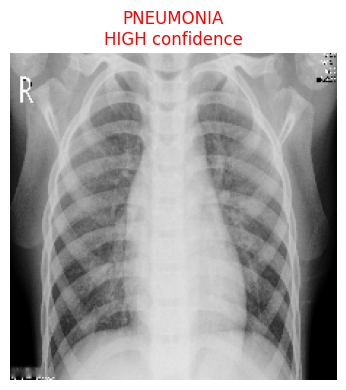

  efficientnet_prob   : 0.755
  densenet_prob       : 0.918
  ensemble_prob       : 0.836
  models_agree        : True
  rule_scores         : {'R1_consolidation_patchy': 1.0, 'R2_ground_glass': 0, 'R3_air_bronchograms': 0.509, 'R4_pleural_effusion': 0.263, 'R5_hyperinflation': 0}
  prediction          : PNEUMONIA
  confidence          : HIGH
  severity            : 8.4/10
  action              : Immediate clinical review — urgent
  top_feature         : consolidation patchy
  explanation         : Both models strongly agree on pneumonia (eff=0.76, den=0.92). Strongest radiological signal: consolidation patchy (score=1.00).


{'efficientnet_prob': 0.755,
 'densenet_prob': 0.918,
 'ensemble_prob': 0.836,
 'models_agree': True,
 'rule_scores': {'R1_consolidation_patchy': 1.0,
  'R2_ground_glass': 0,
  'R3_air_bronchograms': 0.509,
  'R4_pleural_effusion': 0.263,
  'R5_hyperinflation': 0},
 'prediction': 'PNEUMONIA',
 'confidence': 'HIGH',
 'severity': '8.4/10',
 'action': 'Immediate clinical review — urgent',
 'top_feature': 'consolidation patchy',
 'explanation': 'Both models strongly agree on pneumonia (eff=0.76, den=0.92). Strongest radiological signal: consolidation patchy (score=1.00).'}

In [15]:
# ── Load from saved dataset (across sessions) ─────────────
# MODEL_DIR = "/kaggle/input/your-published-dataset-name"
MODEL_DIR = SAVE_DIR   # same session

with open(f"{MODEL_DIR}/config.json") as f:
    cfg = json.load(f)

loaded_eff = tf.keras.models.load_model(
    f"{MODEL_DIR}/eff_final.keras",
    custom_objects={"loss": focal_loss()}
)
loaded_den = tf.keras.models.load_model(
    f"{MODEL_DIR}/den_final.keras",
    custom_objects={"loss": focal_loss()}
)
print("✅ Models reloaded")

reasoner = NeuroSymbolicReasoner(
    loaded_eff, loaded_den,
    w_eff=cfg["w_eff"], w_den=cfg["w_den"]
)

def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path,
                                   target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)   # (1,224,224,3)
    result = reasoner.predict(img_array)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array[0].astype("uint8"))
    color = "red" if "PNEUMONIA" in result["prediction"] else "green"
    plt.title(f"{result['prediction']}\n{result['confidence']} confidence",
              color=color)
    plt.axis("off"); plt.tight_layout(); plt.show()

    for k, v in result.items():
        print(f"  {k:20s}: {v}")
    return result

# Test on one image
sample = TEST_DIR + "/PNEUMONIA/" + os.listdir(TEST_DIR+"/PNEUMONIA")[0]
predict_image(sample)